In [62]:
import mne
import os
import numpy as np
import pandas as pd
import scipy.io
from scipy.signal import butter, filtfilt, welch, windows
from scipy import signal
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import tensorflow as tf
from keras_gcn import GraphConv
import scipy.io
from sklearn.metrics import accuracy_score
seed = 111;
np.random.seed(seed)
tf.random.set_seed(seed)

In [63]:
class SqueezeLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.squeeze(inputs, axis=2)



In [64]:
num_nodes=9 # clusters
node_dim=4 # feature vectors
data_layer = tf.keras.layers.Input(shape=(num_nodes, node_dim))
edge_layer = tf.keras.layers.Input(shape=(num_nodes, num_nodes))
conv_layer = GraphConv(units=300, step_num=3,)([data_layer, edge_layer])
#conv_layer1 = GraphConv(units=500, step_num=3,)([data_layer, edge_layer])

conv_layer2 = GraphConv(units=1, step_num=3,)([conv_layer, edge_layer])
out1 = SqueezeLayer()(conv_layer2)
out2 = tf.keras.layers.Dense(50, 'tanh')(out1)
#out2 = tf.keras.layers.Dense(50, 'tanh')(out2)
out = tf.keras.layers.Dense(2, 'softmax')(out2)
model = tf.keras.Model([data_layer, edge_layer], out)
model.summary()

Model: "model_142"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_285 (InputLayer)      [(None, 9, 4)]               0         []                            
                                                                                                  
 input_286 (InputLayer)      [(None, 9, 9)]               0         []                            
                                                                                                  
 graph_conv_284 (GraphConv)  (None, 9, 300)               1500      ['input_285[0][0]',           
                                                                     'input_286[0][0]']           
                                                                                                  
 graph_conv_285 (GraphConv)  (None, 9, 1)                 301       ['graph_conv_284[0][0]

In [65]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=adam_optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

In [66]:
band = 'theta'
#delta: 0.1-4
#thtea: 4-7
#alpha 8-12
cluster = 5

### Testing

(2640, 9, 4) float64 <class 'numpy.ndarray'>
Epoch 1/50
205/205 [==============================] - 2s 4ms/step - loss: 0.5764 - accuracy: 0.7035 - val_loss: 0.1937 - val_accuracy: 1.0000
Epoch 2/50
205/205 [==============================] - 1s 3ms/step - loss: 0.0277 - accuracy: 1.0000 - val_loss: 0.0049 - val_accuracy: 1.0000
Epoch 3/50
205/205 [==============================] - 1s 3ms/step - loss: 0.0023 - accuracy: 1.0000 - val_loss: 0.0018 - val_accuracy: 1.0000
Epoch 4/50
205/205 [==============================] - 1s 4ms/step - loss: 0.0010 - accuracy: 1.0000 - val_loss: 8.7333e-04 - val_accuracy: 1.0000
Epoch 5/50
205/205 [==============================] - 1s 2ms/step - loss: 5.5206e-04 - accuracy: 1.0000 - val_loss: 4.9478e-04 - val_accuracy: 1.0000
Epoch 6/50
205/205 [==============================] - 1s 3ms/step - loss: 3.5738e-04 - accuracy: 1.0000 - val_loss: 3.8760e-04 - val_accuracy: 1.0000
Epoch 7/50
205/205 [==============================] - 0s 2ms/step - loss: 2.4719e-0

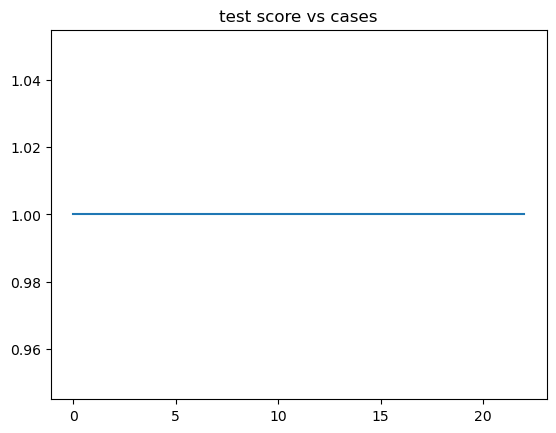

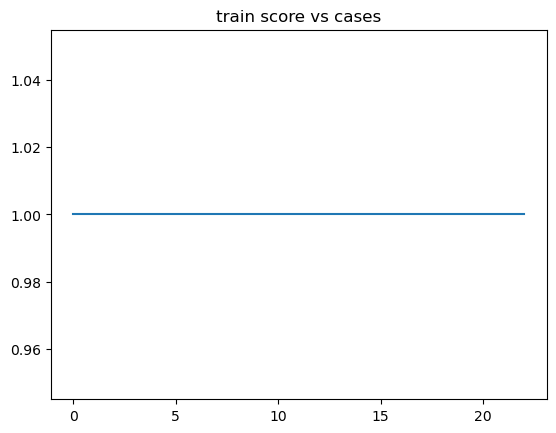

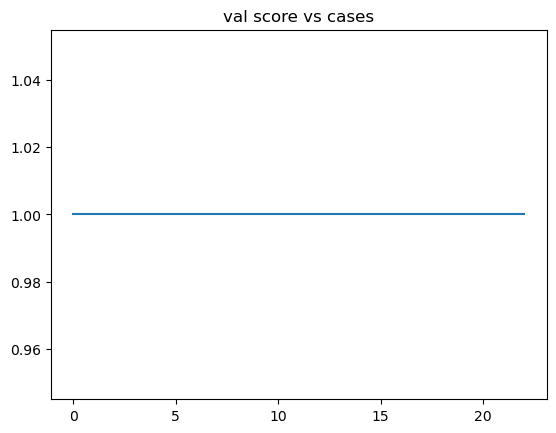

In [67]:
corr_folder = 'E:/sayan_24/GNN_aniket/CSZ_corr_data_' + band + '_cluster_' + str(cluster) + '/'
PSD_folder = 'E:/sayan_24/GNN_aniket/CSZ_PSD_data_' + band + '_cluster_' + str(cluster) + '/'
Label_folder = 'E:/sayan_24/GNN_aniket/CSZ_Label_data_' + band + '_cluster_' + str(cluster) + '/'
test_score = []
train_score = []
val_score = []

for case in range(1, 24):

    corr_csz = scipy.io.loadmat(corr_folder + f'csz_corr_matrix{case}.mat')
    corr_test = scipy.io.loadmat(corr_folder + f'test_corr_matrix{case}.mat')
    corr_he = scipy.io.loadmat(corr_folder + f'he_corr_matrix{case}.mat')

    PSD_csz = scipy.io.loadmat(PSD_folder + f'csz_PSD{case}.mat')
    PSD_test = scipy.io.loadmat(PSD_folder + f'test_PSD{case}.mat')
    PSD_he = scipy.io.loadmat(PSD_folder + f'he_PSD{case}.mat')

    #print(type(PSD_csz))

    label_csz = scipy.io.loadmat(Label_folder + f'csz_label{case}.mat')
    label_test = scipy.io.loadmat(Label_folder + f'test_label{case}.mat')
    label_he = scipy.io.loadmat(Label_folder + f'he_label{case}.mat')

    #print(corr_csz)

    corr_csz = corr_csz['csz_corr_mat']
    corr_test = corr_test['corr_matrix']
    corr_he = corr_he['he_corr_mat']

    PSD_csz = PSD_csz['csz_PSD']
    PSD_test = PSD_test['test_PSD']
    PSD_he = PSD_he['he_PSD']

    print(PSD_csz.shape, PSD_csz.dtype, type(PSD_csz))

    label_csz = label_csz['csz_label']
    label_test = label_test['test_label']
    label_he = label_he['he_label']

    corr_train = np.vstack((corr_csz, corr_he))
    label_train = np.vstack((label_csz, label_he))
    PSD_train = np.vstack((PSD_csz, PSD_he))

    Y = label_train
    Y_test = label_test

    E = corr_train
    E_test = corr_test

    X = PSD_train
    X_test = PSD_test

    num_nodes=9 # clusters
    node_dim=4 # feature vectors
    data_layer = tf.keras.layers.Input(shape=(num_nodes, node_dim))
    edge_layer = tf.keras.layers.Input(shape=(num_nodes, num_nodes))
    conv_layer = GraphConv(units=300, step_num=3,)([data_layer, edge_layer])
    #conv_layer1 = GraphConv(units=500, step_num=3,)([data_layer, edge_layer])

    conv_layer2 = GraphConv(units=1, step_num=3,)([conv_layer, edge_layer])
    out1 = SqueezeLayer()(conv_layer2)
    out2 = tf.keras.layers.Dense(50, 'tanh')(out1)
    #out2 = tf.keras.layers.Dense(50, 'tanh')(out2)
    out = tf.keras.layers.Dense(2, 'softmax')(out2)
    model = tf.keras.Model([data_layer, edge_layer], out)

    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    model.compile(
        optimizer=adam_optimizer,
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=['accuracy']
    )

    training_history = model.fit(
    [X, E],
    Y,
    epochs=50,
    shuffle=True,
    validation_data=([X_test,E_test], Y_test),
    )

    Y_pred = model.predict([X_test, E_test])
    #y_fit = [[1 if value > 0.5 else 0 for value in row] for row in Y_pred]
    y_fit = (Y_pred == np.max(Y_pred, axis=1, keepdims=True)).astype(int)
    accuracy = accuracy_score(Y_test, y_fit)
    #print(Y_pred)
    # print(y_fit)
    print("Accuracy:", accuracy)
    test_score.append(accuracy)
    train_score.append(training_history.history['accuracy'][-1])
    val_score.append(training_history.history['val_accuracy'][-1])

print(test_score)
plt.plot(test_score)
plt.title("test score vs cases")
plt.show()
plt.plot(train_score)
plt.title("train score vs cases")
plt.show()
plt.plot(val_score)
plt.title("val score vs cases")
plt.show()

(2245, 9, 4) float64 <class 'numpy.ndarray'>
Epoch 1/50
217/217 [==============================] - 2s 5ms/step - loss: 0.5587 - accuracy: 0.6986 - val_loss: 0.1716 - val_accuracy: 1.0000
Epoch 2/50
217/217 [==============================] - 1s 3ms/step - loss: 0.0521 - accuracy: 0.9934 - val_loss: 0.0025 - val_accuracy: 1.0000
Epoch 3/50
217/217 [==============================] - 1s 3ms/step - loss: 0.0028 - accuracy: 1.0000 - val_loss: 0.0011 - val_accuracy: 1.0000
Epoch 4/50
217/217 [==============================] - 1s 3ms/step - loss: 0.0012 - accuracy: 1.0000 - val_loss: 6.6144e-04 - val_accuracy: 1.0000
Epoch 5/50
217/217 [==============================] - 1s 3ms/step - loss: 6.8566e-04 - accuracy: 1.0000 - val_loss: 4.2008e-04 - val_accuracy: 1.0000
Epoch 6/50
217/217 [==============================] - 1s 2ms/step - loss: 4.4285e-04 - accuracy: 1.0000 - val_loss: 2.2470e-04 - val_accuracy: 1.0000
Epoch 7/50
217/217 [==============================] - 1s 3ms/step - loss: 3.1036e-0

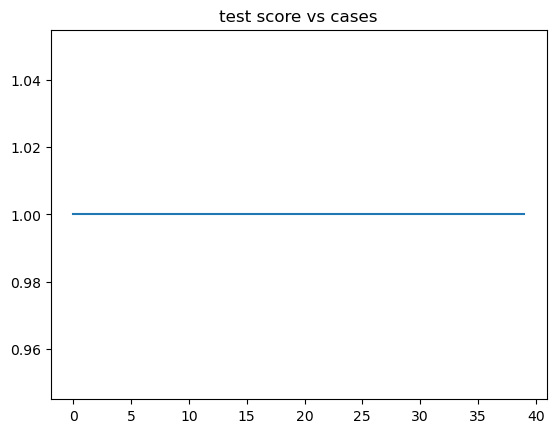

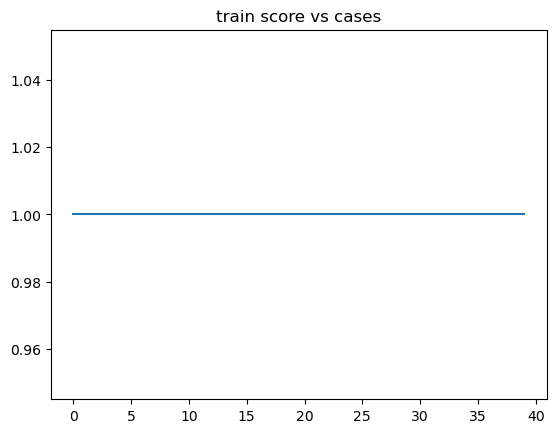

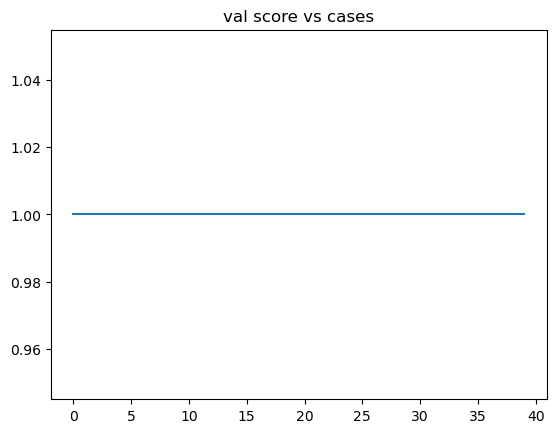

In [68]:
corr_folder = 'E:/sayan_24/GNN_aniket/HE_corr_data_' + band + '_cluster_' + str(cluster) + '/'
PSD_folder ='E:/sayan_24/GNN_aniket/HE_PSD_data_' + band + '_cluster_' + str(cluster) + '/'
Label_folder = 'E:/sayan_24/GNN_aniket/HE_Label_data_' + band + '_cluster_' + str(cluster) + '/'
test_score = []
train_score = []
val_score = []

for case in range(1, 41):

    corr_csz = scipy.io.loadmat(corr_folder + f'csz_corr_matrix{case}.mat')
    corr_test = scipy.io.loadmat(corr_folder + f'test_corr_matrix{case}.mat')
    corr_he = scipy.io.loadmat(corr_folder + f'he_corr_matrix{case}.mat')

    PSD_csz = scipy.io.loadmat(PSD_folder + f'csz_PSD{case}.mat')
    PSD_test = scipy.io.loadmat(PSD_folder + f'test_PSD{case}.mat')
    PSD_he = scipy.io.loadmat(PSD_folder + f'he_PSD{case}.mat')

    #print(type(PSD_csz))

    label_csz = scipy.io.loadmat(Label_folder + f'csz_label{case}.mat')
    label_test = scipy.io.loadmat(Label_folder + f'test_label{case}.mat')
    label_he = scipy.io.loadmat(Label_folder + f'he_label{case}.mat')

    #print(corr_csz)

    corr_csz = corr_csz['csz_corr_mat']
    corr_test = corr_test['corr_matrix']
    corr_he = corr_he['he_corr_mat']

    PSD_csz = PSD_csz['csz_PSD']
    PSD_test = PSD_test['test_PSD']
    PSD_he = PSD_he['he_PSD']

    print(PSD_csz.shape, PSD_csz.dtype, type(PSD_csz))

    label_csz = label_csz['csz_label']
    label_test = label_test['test_label']
    label_he = label_he['he_label']

    corr_train = np.vstack((corr_csz, corr_he))
    label_train = np.vstack((label_csz, label_he))
    PSD_train = np.vstack((PSD_csz, PSD_he))

    Y = label_train
    Y_test = label_test

    E = corr_train
    E_test = corr_test

    X = PSD_train
    X_test = PSD_test

    num_nodes=9 # clusters
    node_dim=4 # feature vectors
    data_layer = tf.keras.layers.Input(shape=(num_nodes, node_dim))
    edge_layer = tf.keras.layers.Input(shape=(num_nodes, num_nodes))
    conv_layer = GraphConv(units=300, step_num=3,)([data_layer, edge_layer])
    #conv_layer1 = GraphConv(units=500, step_num=3,)([data_layer, edge_layer])

    conv_layer2 = GraphConv(units=1, step_num=3,)([conv_layer, edge_layer])
    out1 = SqueezeLayer()(conv_layer2)
    out2 = tf.keras.layers.Dense(50, 'tanh')(out1)
    #out2 = tf.keras.layers.Dense(50, 'tanh')(out2)
    out = tf.keras.layers.Dense(2, 'softmax')(out2)
    model = tf.keras.Model([data_layer, edge_layer], out)

    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    model.compile(
        optimizer=adam_optimizer,
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=['accuracy']
    )

    training_history = model.fit(
    [X, E],
    Y,
    epochs=50,
    shuffle=True,
    validation_data=([X_test,E_test], Y_test),
    )


    Y_pred = model.predict([X_test, E_test])
    #y_fit = [[1 if value > 0.5 else 0 for value in row] for row in Y_pred]
    y_fit = (Y_pred == np.max(Y_pred, axis=1, keepdims=True)).astype(int)
    accuracy = accuracy_score(Y_test, y_fit)
    #print(Y_pred)
    # print(y_fit)
    print("Accuracy:", accuracy)

    test_score.append(accuracy)
    train_score.append(training_history.history['accuracy'][-1])
    val_score.append(training_history.history['val_accuracy'][-1])

print(test_score)
plt.plot(test_score)
plt.title("test score vs cases")
plt.show()
plt.plot(train_score)
plt.title("train score vs cases")
plt.show()
plt.plot(val_score)
plt.title("val score vs cases")
plt.show()